In [1]:
import pandas as pd
import pymc as pm
import numpy as np

In [15]:
import pickle 
import cloudpickle
import plot_hierarchical
import csv
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
   
#pickle_filepath = r"/Users/sydney/git/mobility_inference/results/2025-05-01_fourhundred_hierarchicalweight_no2024/trace_C.pickle"
pickle_filepath = r"/Users/sydney/Desktop/BayesProjectMathcluster/2025-06-05_1000halfnormal_diffparam_b/trace_C.pickle"
name = "2025-06-05_1000halfnormal_diffparam_b"
with open(pickle_filepath , 'rb') as buff:
    model_dict = cloudpickle.load(buff)

trace = model_dict['trace']
model = model_dict['model']
tag = model_dict['tag']
indicators = model_dict['indicators']
chosen_model = model_dict['chosen_model']
dates = model_dict['dates']
temperature = model_dict['temperature']
daylight = model_dict['daylight']
school = model_dict['school']
holiday = model_dict['holiday']
incl2024 = model_dict['incl_2024']
mix_incidence = model_dict['mix_incidence']


In [16]:
rhat = az.rhat(trace)
divergences = trace.sample_stats["diverging"].sum()
divergences

/Users/sydney/git/mobility_inference/myenv/lib/python3.11/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


<xarray.DataArray 'diverging' ()>
array(6)

In [15]:
preteste = plot_hierarchical.concatenate_chains_and_draws(trace.posterior.incidence_weight)
teste = np.median(preteste, axis=0)
test2e = pd.DataFrame(teste)
subDir_named = "/Users/sydney/git/mobility_inference/results/2025-05-01_fourhundred_hierarchicalweight_no2024/"
test2e.to_csv(f"{subDir_named}/sharelocalincidence.csv")

In [11]:
effsamplesize = az.ess(trace)
effsamplesize.median()

KeyboardInterrupt: 

In [17]:
rhat

<xarray.Dataset>
Dimensions:                          (fedState: 345,
                                      incidence_weight_param_dim_0: 1,
                                      incidence_weight_param_dim_1: 345,
                                      obs_id: 17940, incidence_weight_dim_0: 1,
                                      incidence_weight_dim_1: 345,
                                      combined_incidence_dim_0: 61,
                                      combined_incidence_dim_1: 345,
                                      intercept_temperature_dim_0: 345)
Coordinates:
  * fedState                         (fedState) int64 0 1 2 3 ... 342 343 344
  * incidence_weight_param_dim_0     (incidence_weight_param_dim_0) int64 0
  * incidence_weight_param_dim_1     (incidence_weight_param_dim_1) int64 0 ....
  * obs_id                           (obs_id) int64 0 1 2 ... 17937 17938 17939
  * incidence_weight_dim_0           (incidence_weight_dim_0) int64 0
  * incidence_weight_dim_1           (incidence_weight_dim_1) int64 0 1 ... 344
  * combined_incidence_dim_0         (combined_incidence_dim_0) int64 0 1 ... 60
  * combined_incidence_dim_1         (combined_incidence_dim_1) int64 0 ... 344
  * intercept_temperature_dim_0      (intercept_temperature_dim_0) int64 0 .....
Data variables: (12/71)
    mu_dbase_hyperprior              float64 1.765
    sigma_dbase_hyperprior_log__     float64 1.79
    d_factor_tilde                   (fedState) float64 1.26 1.205 ... 1.32
    mu_gamma_log_C                   float64 1.795
    sigma_gamma_C_log__              float64 2.138
    mu_C_tilde                       (fedState) float64 1.277 1.939 ... 1.483
    ...                               ...
    shift_temperature                (fedState) float64 1.734 1.735 ... 1.734
    mu_slope_temp                    float64 1.743
    slope_temperature                (fedState) float64 1.736 1.738 ... 1.736
    intercept_temperature            (intercept_temperature_dim_0) float64 1....
    temperature_factor               (obs_id) float64 1.573 1.69 ... 1.171 1.733
    m                                (obs_id) float64 1.506 1.732 ... 1.617

(array([[884., 116.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [994.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 544., 456.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 541., 459.]]),
 array([0.01085204, 0.18756395, 0.36427586, 0.54098777, 0.71769968,
        0.89441159, 1.0711235 , 1.24783541, 1.42454732, 1.60125923,
        1.77797114]),
 <a list of 4 BarContainer objects>)

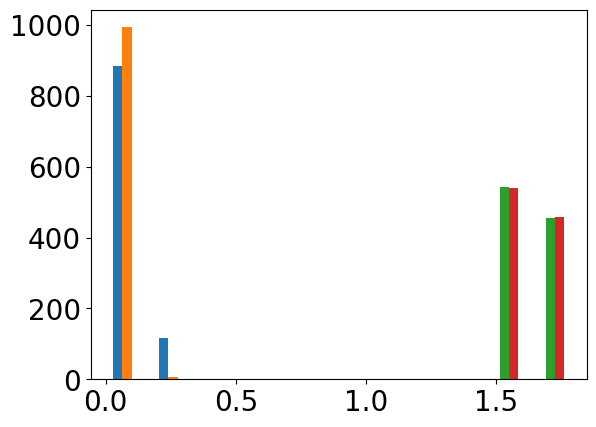

In [18]:
#plt.plot(trace.sample_stats["logp"].T)
#plt.plot(trace.sample_stats["depth"].T)
plt.hist(trace.posterior["sigma_gamma_C"].T)

In [4]:
import data_prep_hierarchical
incl2024 = True

fedState, fedStates, obs_id = data_prep_hierarchical.get_federal_states(chosen_model, incl2024)

In [ ]:
import data_prep_hierarchical

plot_figures = True
precipitation = None
pop_density = None
#incl2024 = False
plus_nat_incidence = False
mix_incidence = True
   
disease_data_raw = {}
disease_data_raw["C"] = data_prep_hierarchical.get_C_raw(chosen_model, incl2024)

disease_data = {}
disease_data["C"] = data_prep_hierarchical.get_C_transformed(chosen_model, incl2024)

fedState, fedStates, obs_id = data_prep_hierarchical.get_federal_states(chosen_model, incl2024)

d_2020_long, d_base_long, dates_long = data_prep_hierarchical.get_out_of_home_duration_long(chosen_model, incl2024)

figdir_name = "figures/" + name
if plot_figures:
        subFigDir_name = figdir_name + "/" + tag
        plot_hierarchical.analysis_figures(
           model, trace, subFigDir_name, dates, dates_long, indicators, school, holiday, temperature, precipitation, daylight, pop_density, disease_data, disease_data_raw, fedState, chosen_model, incl2024, plus_nat_incidence, mix_incidence
        ) 
      
        #plot_hierarchical.plot_disease_timeseries(dates_long, trace, subFigDir_name, indicators, disease_data, disease_data_raw, chosen_model)

Directory  figures/2025-05-15_1000tunes/C  already exists.


/Users/sydney/git/mobility_inference/plot_hierarchical.py:556: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(5, 4))


In [26]:

y_first = trace.posterior.combined_incidence.where(trace.posterior.combined_incidence.combined_incidence_dim_1==1)
y = y_first.dropna(dim="combined_incidence_dim_1", how = "any")
y_test = y[:,:,:,0]
print(y_test.shape)

dates_x = dates_long[dates_long < np.datetime64("2021-03-01")]
#dates = dates_x[dates_x > np.datetime64("2020-03-28")]
dates_plot_long = np.unique(dates_x)

print(dates_plot_long.shape)


# fig, axs = plt.subplots(4, 1, figsize=(9, 20), sharex=False)
# plot_hierarchical.plot_timeseries(
#         axs[0],
#         dates_plot_long,
#         y,
#         color_in="blue",
#         label_in="blue",
# )

(4, 1000, 61)
(61,)


In [23]:
y_first = trace.posterior.risk_C.where((trace.constant_data.counter_C<61)&(trace.constant_data.fedState_idx==1))
y = y_first.dropna(dim="obs_id", how = "any")

print(y.shape)

(4, 1000, 52)


In [4]:
y_first = trace.posterior.combined_incidence.where(trace.posterior.combined_incidence.combined_incidence_dim_1==3)
y_first.dropna(dim="combined_incidence_dim_1", how = "any")

<xarray.DataArray 'combined_incidence' (chain: 4, draw: 1000,
                                        combined_incidence_dim_0: 61,
                                        combined_incidence_dim_1: 1)>
array([[[[1.00000000e-05],
         [1.00000000e-05],
         [1.00000000e-05],
         ...,
         [3.21283080e-01],
         [3.84045884e-01],
         [4.56773167e-01]],

        [[1.00000000e-05],
         [1.00000000e-05],
         [1.00000000e-05],
         ...,
         [3.03467740e-01],
         [3.40069958e-01],
         [3.80994507e-01]],

        [[1.00000000e-05],
         [1.00000000e-05],
         [1.00000000e-05],
         ...,
...
         ...,
         [3.04548222e-01],
         [3.42737052e-01],
         [3.85590405e-01]],

        [[1.00000000e-05],
         [1.00000000e-05],
         [1.00000000e-05],
         ...,
         [3.01234940e-01],
         [3.34558445e-01],
         [3.71497150e-01]],

        [[1.00000000e-05],
         [1.00000000e-05],
         [1.00000000e-05],
         ...,
         [3.08189478e-01],
         [3.51725238e-01],
         [4.01078713e-01]]]])
Coordinates:
  * chain                     (chain) int64 0 1 2 3
  * draw                      (draw) int64 0 1 2 3 4 5 ... 995 996 997 998 999
  * combined_incidence_dim_0  (combined_incidence_dim_0) int64 0 1 2 ... 59 60
  * combined_incidence_dim_1  (combined_incidence_dim_1) int64 3

In [6]:
    #Create output for post-processing
pretest = plot_hierarchical.concatenate_chains_and_draws(trace.posterior.d_C)
test = np.median(pretest, axis=0)
test2 = pd.DataFrame(test)
subDir_name = "results/" + name
test2.to_csv(f"{subDir_name}/d_C.csv")
    
pretestb = plot_hierarchical.concatenate_chains_and_draws(trace.posterior.factor_C)
testb = np.median(pretestb, axis=0)
test2b = pd.DataFrame(testb)
subDir_nameb = "results/" + name
test2b.to_csv(f"{subDir_nameb}/factor_C.csv")
        
pretestc = plot_hierarchical.concatenate_chains_and_draws(trace.posterior.multiplicator_C)
testc = np.median(pretestc, axis=0)
test2c = pd.DataFrame(testc)
subDir_namec = "results/" + name
test2c.to_csv(f"{subDir_namec}/multiplicator_C.csv")
        
pretestd = plot_hierarchical.concatenate_chains_and_draws(trace.posterior.slope_C)
testd = np.median(pretestd, axis=0)
test2d = pd.DataFrame(testd)
subDir_named = "results/" + name
test2d.to_csv(f"{subDir_named}/slope_C.csv")

ValueError: invalid mode: 'output.csv'

In [7]:
trace.constant_data.C_nat

<xarray.DataArray 'C_nat' (obs_id_long: 1808)>
array([1.e-05, 1.e-05, 1.e-05, ..., 1.e-05, 1.e-05, 1.e-05])
Coordinates:
  * obs_id_long  (obs_id_long) int64 0 1 2 3 4 5 ... 1803 1804 1805 1806 1807

In [2]:
trace.posterior

<xarray.Dataset>
Dimensions:                       (chain: 4, draw: 1000, fedState: 16,
                                   obs_id: 832, combined_incidence_dim_0: 61,
                                   combined_incidence_dim_1: 16,
                                   intercept_temperature_dim_0: 16)
Coordinates:
  * chain                         (chain) int64 0 1 2 3
  * draw                          (draw) int64 0 1 2 3 4 ... 995 996 997 998 999
  * fedState                      (fedState) int64 0 1 2 3 4 ... 11 12 13 14 15
  * obs_id                        (obs_id) int64 0 1 2 3 4 ... 828 829 830 831
  * combined_incidence_dim_0      (combined_incidence_dim_0) int64 0 1 ... 59 60
  * combined_incidence_dim_1      (combined_incidence_dim_1) int64 0 1 ... 14 15
  * intercept_temperature_dim_0   (intercept_temperature_dim_0) int64 0 1 ... 15
Data variables: (12/69)
    mu_dbase_hyperprior           (chain, draw) float64 -0.1951 ... -0.1771
    sigma_dbase_hyperprior_log__  (chain, draw) float64 -3.213 -3.165 ... -3.375
    d_factor_tilde                (chain, draw, fedState) float64 1.244 ... 0...
    mu_gamma_log_C                (chain, draw) float64 1.886 2.819 ... 1.856
    sigma_gamma_C_log__           (chain, draw) float64 1.01 1.01 ... 1.165
    mu_C_tilde                    (chain, draw, fedState) float64 11.47 ... 4...
    ...                            ...
    shift_temperature             (chain, draw, fedState) float64 11.15 ... 1...
    mu_slope_temp                 (chain, draw) float64 4.202 3.954 ... 4.015
    slope_temperature             (chain, draw, fedState) float64 4.251 ... 4...
    intercept_temperature         (chain, draw, intercept_temperature_dim_0) float64 ...
    temperature_factor            (chain, draw, obs_id) float64 0.9597 ... 1.018
    m                             (chain, draw, obs_id) float64 6.641 ... 6.998
Attributes:
    created_at:                 2025-04-25T06:35:23.613164
    arviz_version:              0.17.0
    inference_library:          nutpie
    inference_library_version:  0.13.2
    sampling_time:              157.7220230102539